# Annotating proteins from UniProt

SHEPHARD can pull annotations directly from the [UniProt REST API](https://www.uniprot.org/help/api) and convert them into SHEPHARD `Domains`, `Sites` and `Tracks`. This notebook walks through that functionality.

**What this notebook covers**

1. [Setup](#setup)
2. [Discovering what you can ask for](#discovering)
3. [Annotating a single protein](#single)
4. [What you get back: Domains and Sites](#what)
5. [Disulfide bonds and cross-links](#bonds)
6. [Annotation metadata and provenance](#metadata)
7. [Controlling what gets fetched](#controlling)
8. [Experimental structures and Tracks](#structures)
9. [Annotating a whole proteome (batched)](#batch)
10. [Error handling](#errors)
11. [Saving annotations for reproducibility](#saving)
12. [Putting it together: a real question](#question)

**Requirements**: this notebook makes live calls to UniProt, so it needs network access. It adds no dependencies beyond SHEPHARD itself (the requests are made with the Python standard library). The final section uses `matplotlib` for one figure.

<a id='setup'></a>
## 1. Setup

We need two things: the `uniprot` API module, and a `Proteome` to annotate.

SHEPHARD ships with a small nine-protein test set that we can use throughout. Because it was built from a UniProt FASTA file, each protein's `unique_ID` is already a UniProt accession — which is exactly what the annotation functions expect by default.

In [1]:
import shephard
from shephard.apis import uniprot

# the nine-protein test set bundled with SHEPHARD
test_data = shephard.get_data('test_data')
P = uniprot.uniprot_fasta_to_proteome(f'{test_data}/testset_1.fasta')

print(P)
print('unique_IDs:', P.proteins)

[Proteome]: Sequence dataset with 9 protein records
unique_IDs: ['O00401', 'O00470', 'O00472', 'O00499', 'O00629', 'O00712', 'O00716', 'O14786', 'Q9UJX3']


<a id='discovering'></a>
## 2. Discovering what you can ask for

Annotations are grouped into *annotation groups*, each controlled by its own keyword argument. `uniprot_annotation_groups()` lists them all, so you never have to guess a keyword name.

In [3]:
groups

['active_sites',
 'binding_sites',
 'coiled_coils',
 'compositional_bias',
 'cross_links',
 'disulfide_bonds',
 'dna_binding',
 'domains',
 'glycosylation',
 'lipidation',
 'modified_residues',
 'molecule_processing',
 'motifs',
 'mutagenesis',
 'natural_variants',
 'other_sites',
 'regions',
 'repeats',
 'secondary_structure',
 'transmembrane',
 'zinc_fingers']

In [4]:
groups = uniprot.uniprot_annotation_groups()

print(f'{len(groups)} annotation groups available:\n')
for group in groups:
    features = uniprot.UNIPROT_ANNOTATION_GROUPS[group]['types']
    print(f"  {group:22s} -> {', '.join(features)}")

21 annotation groups available:

  active_sites           -> Active site
  binding_sites          -> Binding site
  coiled_coils           -> Coiled coil
  compositional_bias     -> Compositional bias
  cross_links            -> Cross-link
  disulfide_bonds        -> Disulfide bond
  dna_binding            -> DNA binding
  domains                -> Domain
  glycosylation          -> Glycosylation
  lipidation             -> Lipidation
  modified_residues      -> Modified residue
  molecule_processing    -> Chain, Peptide, Propeptide, Signal, Transit peptide, Initiator methionine
  motifs                 -> Motif
  mutagenesis            -> Mutagenesis
  natural_variants       -> Natural variant
  other_sites            -> Site
  regions                -> Region
  repeats                -> Repeat
  secondary_structure    -> Helix, Beta strand, Turn
  transmembrane          -> Transmembrane, Intramembrane, Topological domain
  zinc_fingers           -> Zinc finger


Most groups are on by default. Four are off, because they are either dominated by a feature that spans the whole protein (`molecule_processing`), describe experiments rather than the native protein (`mutagenesis`, `natural_variants`), or are usually more useful as a Track than as Domains (`secondary_structure`).

There is also a helper for checking that something looks like a UniProt accession. SHEPHARD uses this internally to reject malformed accessions *before* they reach the API — one bad accession in a batch would otherwise fail the whole request.

In [5]:
for candidate in ['P01308', 'P04637-2', 'A0A023GPI8', 'my_protein_1', 'p01308', '']:
    print(f'{candidate!r:16s} -> {uniprot.is_valid_uniprot_accession(candidate)}')

'P01308'         -> True
'P04637-2'       -> True
'A0A023GPI8'     -> True
'my_protein_1'   -> False
'p01308'         -> False
''               -> False


<a id='single'></a>
## 3. Annotating a single protein

`annotate_protein_with_uniprot()` takes a single `Protein` and annotates it with one API call.

We will use human insulin (**P01308**) as our example. It is small (110 residues), and it carries a nice spread of annotation types — a signal peptide, two chains, and three disulfide bonds.

To annotate a protein we first need one, so we build a single-protein `Proteome` from insulin's sequence.

In [6]:
from shephard.proteome import Proteome

# human insulin, UniProt P01308
insulin_sequence = ('MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGG'
                    'GPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN')

insulin_proteome = Proteome([{'sequence': insulin_sequence,
                              'name': 'Insulin',
                              'unique_ID': 'P01308',
                              'attributes': {}}])

insulin = insulin_proteome.protein('P01308')
print(insulin)

| Protein: P01308 - L=110, #t=0, #d=0, #s=0, #a=0 |


Now we annotate it. Note we ask for `molecule_processing` as well as the defaults, because for insulin the signal peptide and chains are the interesting part.

The function returns a summary of what it actually did.

In [7]:
summary = uniprot.annotate_protein_with_uniprot(insulin, molecule_processing=True)

print(summary)

{'domains': 4, 'sites': 6, 'tracks': 0, 'skipped': 0}


<a id='what'></a>
## 4. What you get back: Domains and Sites

UniProt features are mapped onto SHEPHARD annotations by their **shape**, not by their name:

| UniProt feature | Becomes |
|---|---|
| spans a range of residues | a `Domain` |
| sits on a single residue | a `Site` |
| a disulfide bond or cross-link | a **pair** of `Sites` |

This means a feature type that is sometimes a point and sometimes a range (a binding site, say) is always handled sensibly.

In [8]:
print('DOMAINS')
for d in insulin.domains:
    print(f"  {d.start:4d}-{d.end:<4d} {d.domain_type:28s} {d.attribute('description')}")

print('\nSITES')
for s in sorted(insulin.sites, key=lambda x: x.position):
    print(f"  {s.position:4d}      {s.site_type:28s} {s.attribute('description')}")

DOMAINS
     1-24   uniprot_signal               
    25-54   uniprot_peptide              Insulin B chain
    57-87   uniprot_propeptide           C peptide
    90-110  uniprot_peptide              Insulin A chain

SITES
    31      uniprot_disulfide_bond       Interchain (between B and A chains)
    43      uniprot_disulfide_bond       Interchain (between B and A chains)
    95      uniprot_disulfide_bond       
    96      uniprot_disulfide_bond       Interchain (between B and A chains)
   100      uniprot_disulfide_bond       
   109      uniprot_disulfide_bond       Interchain (between B and A chains)


Note the naming convention: every annotation type is prefixed with `uniprot_` (configurable via the `prefix` argument), so UniProt-derived annotations never collide with your own.

Because these are ordinary SHEPHARD annotations, all the usual accessors work:

In [9]:
# the mature insulin B chain, straight out of the Domain object
b_chain = [d for d in insulin.get_domains_by_type('uniprot_peptide')
           if 'B chain' in d.attribute('description')][0]

print(f"{b_chain.attribute('description')}: residues {b_chain.start}-{b_chain.end}")
print(f'sequence: {b_chain.sequence}')
print(f'length  : {len(b_chain)}')

Insulin B chain: residues 25-54
sequence: FVNQHLCGSHLVEALYLVCGERGFFYTPKT
length  : 30


<a id='bonds'></a>
## 5. Disulfide bonds and cross-links

Disulfide bonds are worth a closer look, because they are the one case where the obvious mapping would be wrong.

UniProt encodes a disulfide bond with a start and an end position — but those two positions are **bonded partners**, not the boundaries of a region. Adding a `Domain` spanning them would assert a contiguous region that does not exist.

SHEPHARD therefore adds a `Site` on *each* partner, and records where the other one is in the `partner_position` attribute.

In [10]:
disulfides = insulin.get_sites_by_type('uniprot_disulfide_bond', return_list=True)

print(f'{len(disulfides)} disulfide Sites ({len(disulfides)//2} bonds)\n')

for s in sorted(disulfides, key=lambda x: x.position):
    partner = s.attribute('partner_position', safe=False)
    print(f'  Cys{s.position:<4d} bonded to position {partner}')

6 disulfide Sites (3 bonds)

  Cys31   bonded to position 96
  Cys43   bonded to position 109
  Cys95   bonded to position 100
  Cys96   bonded to position 31
  Cys100  bonded to position 95
  Cys109  bonded to position 43


So the three disulfide bonds of insulin become six Sites, and from any one of them you can find its partner. Cross-links (`uniprot_cross_link`) are handled the same way.

<a id='metadata'></a>
## 6. Annotation metadata and provenance

Every annotation carries an attribute dictionary, so you can always ask where something came from and how strong the evidence is. This matters: six months later, "why is there a domain here?" should have an answer.

In [11]:
domain = insulin.get_domains_by_type('uniprot_peptide')[0]

for key in domain.attributes:
    print(f'  {key:24s} {domain.attribute(key)}')

  source                   uniprot
  uniprot_accession        P01308
  uniprot_feature_type     Peptide
  description              Insulin B chain
  uniprot_feature_id       PRO_0000015819


The `evidence` attribute holds UniProt's evidence codes in flattened form — [ECO codes](https://www.evidenceontology.org/), qualified by their source where there is one. `ECO:0000269|PubMed:...` means experimental evidence from a specific paper; `ECO:0000255` means it was inferred by an automatic annotation rule.

This lets you filter on evidence quality, which is often what you want for a serious analysis:

In [12]:
experimental = []
inferred = []

for d in insulin.domains:
    evidence = d.attribute('evidence', safe=False) or ''

    if 'ECO:0000269' in evidence:
        experimental.append(d)
    else:
        inferred.append(d)

print(f'{len(experimental)} domains with experimental evidence, {len(inferred)} inferred or unevidenced')

1 domains with experimental evidence, 3 inferred or unevidenced


<a id='controlling'></a>
## 7. Controlling what gets fetched

Each annotation group has its own keyword, so you can ask for exactly what your analysis needs. This is not just tidiness — only the data required for the requested groups is downloaded, so a narrow request is a meaningfully smaller and faster one.

Here we ask for *only* modified residues, on a protein that has some (insulin has none, so it would make a poor demonstration).

In [13]:
# a fresh copy of the test proteome, so we start from a clean slate
ptm_only = uniprot.uniprot_fasta_to_proteome(f'{test_data}/testset_1.fasta')

uniprot.annotate_protein_with_uniprot(
    ptm_only.protein('O00712'),
    # everything off ...
    domains=False, regions=False, motifs=False, repeats=False,
    zinc_fingers=False, coiled_coils=False, compositional_bias=False,
    dna_binding=False, transmembrane=False, binding_sites=False,
    active_sites=False, other_sites=False, glycosylation=False,
    lipidation=False, disulfide_bonds=False, cross_links=False,
    # ... except this one
    modified_residues=True)

target = ptm_only.protein('O00712')
print(f'{target.unique_ID}: {len(target.domains)} domains, {len(target.sites)} sites')

for s in sorted(target.sites, key=lambda x: x.position):
    print(f"  {s.position:4d}  {s.attribute('description')}")

O00712: 0 domains, 9 sites
   264  Phosphoserine
   286  Phosphothreonine
   292  Phosphoserine
   295  Phosphoserine
   312  Phosphoserine
   328  Phosphoserine
   333  Phosphoserine
   335  Asymmetric dimethylarginine
   388  Asymmetric dimethylarginine


<a id='structures'></a>
## 8. Experimental structures and Tracks

UniProt records which regions of a protein have been resolved experimentally, via its PDB cross-references. SHEPHARD can turn this into two things:

* `experimental_structures=True` — a `Domain` per structurally-resolved region, carrying the PDB ID, method, resolution and chains
* `structure_coverage_track=True` — a per-residue values `Track` that is 1 where a structure exists and 0 where it does not

There is also `secondary_structure_track=True`, which gives a symbols `Track` of UniProt's secondary structure (`H` helix, `E` strand, `T` turn, `-` none).

We will use neuropilin-1 (**O14786**) from the test set, which is partially structurally characterized — the interesting case.

In [14]:
npn1 = P.protein('O14786')

uniprot.annotate_protein_with_uniprot(npn1,
                                      experimental_structures=True,
                                      secondary_structure_track=True,
                                      structure_coverage_track=True)

structures = npn1.get_domains_by_type('uniprot_experimental_structure')

print(f'{npn1.unique_ID}: {len(npn1)} residues, {len(structures)} structurally-resolved regions\n')
for d in structures:
    print(f"  {d.attribute('pdb_id')}  {d.attribute('method'):6s} {d.attribute('resolution'):>8s}  "
          f"covers {d.start}-{d.end}")

O14786: 923 residues, 25 structurally-resolved regions

  2QQM  X-ray    2.00 A  covers 141-586
  8C5G  X-ray    2.70 A  covers 271-586
  1KEX  X-ray    1.90 A  covers 273-427
  2QQI  X-ray    1.80 A  covers 273-586
  2QQN  X-ray    2.20 A  covers 273-427
  3I97  X-ray    2.90 A  covers 273-427
  4RN5  X-ray    1.73 A  covers 273-427
  5C7G  X-ray    1.45 A  covers 273-427
  5IJR  X-ray    1.52 A  covers 273-427
  5IYY  X-ray    1.60 A  covers 273-427
  5J1X  X-ray    2.10 A  covers 273-427
  5JGI  X-ray    1.38 A  covers 273-427
  5JGQ  X-ray    1.60 A  covers 273-427
  5JHK  X-ray    1.80 A  covers 273-427
  6FMC  X-ray    0.90 A  covers 273-427
  6FMF  X-ray    2.81 A  covers 273-427
  6TKK  X-ray    1.06 A  covers 273-427
  7JJC  X-ray    2.36 A  covers 273-427
  7O1N  X-ray    1.56 A  covers 273-427
  7P5U  X-ray    1.60 A  covers 273-427
  8PFE  X-ray    1.35 A  covers 273-427
  9EOU  X-ray    1.55 A  covers 273-586
  9F6B  X-ray    1.57 A  covers 273-427
  4DEQ  X-ray    2.65 A 

In [15]:
coverage = npn1.track('uniprot_structure_coverage').values
secondary = npn1.track('uniprot_secondary_structure').symbols

print(f'structurally covered: {sum(coverage)/len(coverage):.0%} of residues')
print(f'secondary structure : {secondary.count("H")} helix, '
      f'{secondary.count("E")} strand, {secondary.count("T")} turn residues')

structurally covered: 68% of residues
secondary structure : 39 helix, 338 strand, 30 turn residues


Because these are ordinary Tracks, they plot like any other per-residue quantity. Below we show where the structural information actually is along the sequence — the gaps are the parts of WASP that no one has solved.

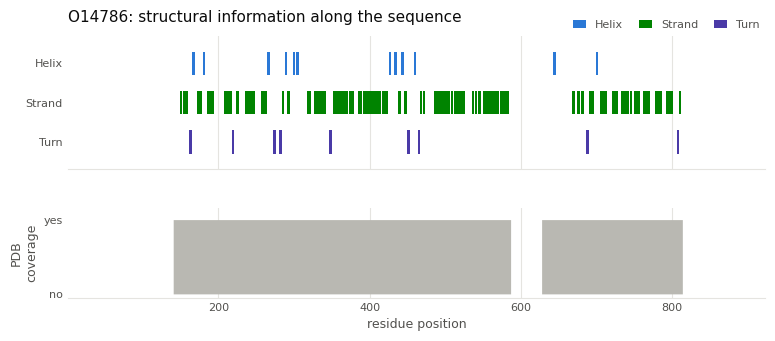

In [17]:
import matplotlib.pyplot as plt

# --- data ------------------------------------------------------------------
positions = range(1, len(npn1) + 1)

lanes = [('Helix',  'H', '#2a78d6'),
         ('Strand', 'E', '#008300'),
         ('Turn',   'T', '#4a3aa7')]

def runs(symbols, target):
    """Contiguous (start, width) runs of `target`, in 1-indexed positions."""
    out, start = [], None
    for idx, symbol in enumerate(symbols, start=1):
        if symbol == target and start is None:
            start = idx
        elif symbol != target and start is not None:
            out.append((start, idx - start))
            start = None
    if start is not None:
        out.append((start, len(symbols) + 1 - start))
    return out

# --- figure ----------------------------------------------------------------
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e5e4e0'

fig, (ax_ss, ax_cov) = plt.subplots(2, 1, figsize=(9, 3.4), sharex=True,
                                    gridspec_kw={'height_ratios': [1.5, 1],
                                                 'hspace': 0.35})

# secondary structure: one lane per type, so identity is carried by position
# as well as by colour
for row, (label, symbol, colour) in enumerate(lanes):
    ax_ss.broken_barh(runs(secondary, symbol), (row - 0.3, 0.6),
                      facecolors=colour, edgecolors='none', label=label)

ax_ss.set_yticks(range(len(lanes)))
ax_ss.set_yticklabels([label for label, _, _ in lanes])
ax_ss.set_ylim(-0.7, len(lanes) - 0.3)
ax_ss.invert_yaxis()
ax_ss.set_title(f'{npn1.unique_ID}: structural information along the sequence',
                loc='left', color=INK, fontsize=11, pad=10)
ax_ss.legend(loc='lower right', bbox_to_anchor=(1, 1.0), ncol=3, frameon=False,
             fontsize=8, labelcolor=MUTED, handlelength=1.2, borderpad=0,
             columnspacing=1.4)

# structural coverage: a single series, so no legend - the axis label names it
ax_cov.fill_between(positions, list(coverage), step='mid',
                    color='#b9b8b2', linewidth=0)
ax_cov.set_yticks([0, 1])
ax_cov.set_yticklabels(['no', 'yes'])
ax_cov.set_ylim(-0.05, 1.15)
ax_cov.set_ylabel('PDB\ncoverage', color=MUTED, fontsize=9)
ax_cov.set_xlabel('residue position', color=MUTED, fontsize=9)
ax_cov.set_xlim(1, len(npn1))

# recessive chrome
for ax in (ax_ss, ax_cov):
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8, length=0)
    ax.grid(axis='x', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

plt.show()

Read together, the two panels say something useful. The bulk of neuropilin-1's extracellular region is solved and is overwhelmingly beta — the strand lane is dense where the coverage is — while the N-terminal signal region and the C-terminal cytoplasmic tail have no experimental structure at all. Those unresolved ends are exactly the regions you would want to hand to a disorder predictor.

Because the coverage Track is an ordinary values Track, you can feed it straight to `domain_tools` to turn "structurally dark" into Domains you can analyse:

In [18]:
from shephard.tools import domain_tools
from shephard.interfaces import si_domains

def uncovered(values):
    return [1 if v == 0 else 0 for v in values]

dark = domain_tools.build_domains_from_track_values(
    P, 'uniprot_structure_coverage', uncovered, 'structurally_dark',
    minimum_region_size=30, verbose=False)

si_domains.add_domains_from_dictionary(P, dark)

for d in npn1.get_domains_by_type('structurally_dark'):
    print(f'  structurally dark: {d.start}-{d.end} ({len(d)} residues)')

  structurally dark: 1-140 (140 residues)
  structurally dark: 587-627 (41 residues)
  structurally dark: 814-923 (110 residues)


<a id='batch'></a>
## 9. Annotating a whole proteome (batched)

Everything so far used one protein and one API call. For real work you want a whole proteome, and you do **not** want one call per protein.

`annotate_proteome_with_uniprot()` batches accessions — by default 100 per request — so annotating a few thousand proteins costs a few tens of calls. Duplicate accessions are collapsed, and malformed ones are rejected locally before they reach UniProt.

The rest of the behaviour is identical: the two functions share the same conversion engine internally, so annotating one protein and annotating a proteome always give the same answer.

In [19]:
# a fresh copy of the test proteome
P2 = uniprot.uniprot_fasta_to_proteome(f'{test_data}/testset_1.fasta')

# safe=False means one problem protein is reported rather than aborting the run
summary = uniprot.annotate_proteome_with_uniprot(P2, safe=False, verbose=False)

print(f"{'unique_ID':12s} {'domains':>8s} {'sites':>7s}   note")
for unique_ID in sorted(summary):
    result = summary[unique_ID]
    note = result.get('error', '')
    print(f"{unique_ID:12s} {result['domains']:8d} {result['sites']:7d}   {note}")

unique_ID     domains   sites   note
O00401             12       6   
O00470              7       0   
O00472             10       2   
O00499              8       7   
O00629             14       2   
O00712              7       9   
O00716             13       0   
O14786              9      24   
Q9UJX3              0       0   sequence mismatch


Note the last line. `Q9UJX3` was **not** annotated, and the summary says why.

This is the sequence check doing its job. UniProt annotations are *positional* — they are statements about residue numbers — so applying them to a sequence that has changed produces annotations that are silently wrong rather than absent, which is a far more dangerous failure than an error.

The FASTA file bundled with SHEPHARD predates a UniProt revision of this entry:

In [20]:
import json, urllib.request

local = P2.protein('Q9UJX3').sequence
raw = urllib.request.urlopen(f'{uniprot.UNIPROT_REST_URL}/Q9UJX3.json?fields=sequence', timeout=30).read()
current = json.loads(raw)['sequence']['value']

print(f'our copy      : {len(local)} residues')
print(f'UniProt today : {len(current)} residues')

our copy      : 599 residues
UniProt today : 565 residues


Had we annotated anyway, every position past the edit would have been wrong. If you genuinely want to override the check — for example when working with a deliberately modified sequence — pass `verify_sequence=False`.

<a id='errors'></a>
## 10. Error handling

The `safe` keyword decides what happens when something goes wrong: a missing accession, a sequence mismatch, an annotation that falls outside the protein, or a clash with an existing annotation.

* `safe=True` (default) — raise an `APIException`
* `safe=False` — skip, record it in the summary, and carry on

For interactive work `safe=True` is a good default. For a long proteome-scale job, `safe=False` means a handful of stale accessions cannot throw away an hour of work.

In [18]:
from shephard.exceptions import APIException

# a validly-formatted accession that does not exist in UniProt
missing = Proteome([{'sequence': 'ACDEFGHIKL', 'name': 'nope',
                     'unique_ID': 'A0A000A000', 'attributes': {}}])

try:
    uniprot.annotate_protein_with_uniprot(missing.protein('A0A000A000'))
except APIException as e:
    print('safe=True  ->', str(e)[:80])

result = uniprot.annotate_protein_with_uniprot(missing.protein('A0A000A000'),
                                               safe=False, verbose=False)
print('safe=False ->', result)

safe=True  -> UniProt returned no record for accession [A0A000A000]


safe=False -> {'domains': 0, 'sites': 0, 'tracks': 0, 'skipped': 0, 'error': 'no record returned'}


In [19]:
# a unique_ID that is not a UniProt accession at all - caught locally, so this
# never reaches the API
local_ids = Proteome([{'sequence': 'ACDEFGHIKL', 'name': 'mine',
                       'unique_ID': 'my_protein_1', 'attributes': {}}])

print(uniprot.annotate_protein_with_uniprot(local_ids.protein('my_protein_1'),
                                            safe=False, verbose=False))

{'domains': 0, 'sites': 0, 'tracks': 0, 'skipped': 0, 'error': 'invalid accession'}


If your proteins are keyed by something other than a UniProt accession, you do not have to rename them — tell SHEPHARD how to find the accession instead. For a single protein pass `accession=`; for a proteome pass a function via `accession_from_protein=`.

In [20]:
# unique_ID is a local name; the accession lives in an attribute
custom = Proteome([{'sequence': insulin_sequence, 'name': 'insulin',
                    'unique_ID': 'my_protein_1',
                    'attributes': {'accession': 'P01308'}}])

summary = uniprot.annotate_proteome_with_uniprot(
    custom, accession_from_protein=lambda protein: protein.attribute('accession'))

print(summary['my_protein_1'])

{'domains': 0, 'sites': 6, 'tracks': 0, 'skipped': 0}


Network problems are handled separately and always raise. Rate-limited (HTTP 429) and transient server-side (5xx) responses are retried with exponential backoff, honouring UniProt's `Retry-After` header; use `n_retries` to control how persistent this is, and `timeout` to bound each request.

<a id='saving'></a>
## 11. Saving annotations for reproducibility

UniProt is a moving target, and it is a free public resource. For both reasons, fetch once and save, rather than re-querying every time you run an analysis.

Once written to SHEPHARD files, your annotations are fixed, fast to reload, and shareable alongside a paper.

One wrinkle to be aware of: SHEPHARD files use `:` to separate an attribute's key from its value, so any colon *inside* a value is replaced with `-` when written. Evidence strings are the place you will notice this — `ECO:0000255|PROSITE-ProRule:PRU00410` comes back as `ECO-0000255|PROSITE-ProRule-PRU00410`. The code is still identifiable, but if you need byte-exact ECO strings, keep the annotated Proteome in memory or store them in your own format.

In [21]:
import tempfile, os
from shephard.interfaces import si_domains, si_sites

outdir = tempfile.mkdtemp()

si_domains.write_domains(P2, os.path.join(outdir, 'uniprot_domains.tsv'))
si_sites.write_sites(P2, os.path.join(outdir, 'uniprot_sites.tsv'))

# ... and read them straight back into a fresh Proteome
P3 = uniprot.uniprot_fasta_to_proteome(f'{test_data}/testset_1.fasta')
si_domains.add_domains_from_file(P3, os.path.join(outdir, 'uniprot_domains.tsv'))
si_sites.add_sites_from_file(P3, os.path.join(outdir, 'uniprot_sites.tsv'))

print(f'wrote and reloaded {len(P3.domains)} domains and {len(P3.sites)} sites')

# the attributes survive the round trip, so provenance is preserved
d = P3.protein('O00401').domains[0]
print(f"\nexample: {d.domain_type} {d.start}-{d.end}")
print(f"  description: {d.attribute('description')}")
print(f"  evidence   : {d.attribute('evidence', safe=False)}")

wrote and reloaded 80 domains and 50 sites

example: uniprot_domain 34-141
  description: WH1
  evidence   : ECO-0000255|PROSITE-ProRule-PRU00410


<a id='question'></a>
## 12. Putting it together: a real question

Finally, the point of all this. Once annotations are in SHEPHARD they are just objects in a hierarchy, so asking a question of them is a traversal rather than a parsing exercise.

UniProt annotates disordered regions (via MobiDB-lite) as `Region` features described as "Disordered", and post-translational modifications as `Modified residue` features. So we can ask a genuine question directly: **are PTMs enriched in disordered regions?**

In [22]:
disordered_residues = 0
ptms_in_disorder = 0

for protein in P2:

    # the disordered regions UniProt reports for this protein
    disordered = [d for d in protein.get_domains_by_type('uniprot_region')
                  if d.attribute('description') == 'Disordered']

    for region in disordered:
        disordered_residues += len(region)
        ptms_in_disorder += len(region.get_sites_by_type('uniprot_modified_residue',
                                                         return_list=True))

total_residues = sum([len(protein) for protein in P2])
total_ptms = len(P2.get_sites_by_type('uniprot_modified_residue'))

print(f'disordered residues : {disordered_residues} / {total_residues} '
      f'({disordered_residues/total_residues:.1%} of the proteome)')
print(f'PTMs in disorder    : {ptms_in_disorder} / {total_ptms} '
      f'({ptms_in_disorder/total_ptms:.1%} of all PTMs)')

if disordered_residues and ptms_in_disorder:
    enrichment = (ptms_in_disorder/disordered_residues) / (total_ptms/total_residues)
    print(f'\nenrichment          : {enrichment:.2f}x')

disordered residues : 1003 / 5056 (19.8% of the proteome)
PTMs in disorder    : 18 / 27 (66.7% of all PTMs)

enrichment          : 3.36x


Nine proteins is far too small a sample to conclude anything — but the code above is *identical* for a whole proteome. That is the point: swap the FASTA file for the human proteome and the same few lines answer the question at scale.

(For the record, this analysis done properly — with corrections for sequence composition and solvent accessibility — is in [Ginell *et al.*, *Bioinformatics*, 2023](https://doi.org/10.1093/bioinformatics/btad488).)

## Where to go next

* The [API documentation](https://shephard.readthedocs.io/en/latest/apis.html) documents every annotation group and keyword
* `help(uniprot.annotate_proteome_with_uniprot)` works too, and lists every argument
* More SHEPHARD notebooks live in the [shephard-colab repository](https://github.com/holehouse-lab/shephard-colab)
* Precomputed annotations for many model proteomes are in [shephard-data](https://github.com/holehouse-lab/shephard-data)